# 과제 1 - SVM 회귀


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [ ]:
# from sklearn.datasets import fetch_openml
# boston = fetch_openml(name="boston", as_frame=False)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



In [ ]:
from tensorflow.keras.datasets import boston_housing #tensorflow에서 제공하는 데이터세트로 대신 수행
from sklearn.model_selection import train_test_split

# 데이터 로드
(X_train_full, y_train_full), (X_test_full, y_test_full) = boston_housing.load_data()
X = np.vstack((X_train_full, X_test_full))
y = np.concatenate((y_train_full, y_test_full))

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 모델 생성
svr = LinearSVR(epsilon = 10)

# 모델 훈련
svr.fit(X_train, y_train)

LinearSVR(epsilon=10)

In [ ]:
# 예측
y_pred = svr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 105.69820454018395
R-squared: -0.16370649164693774


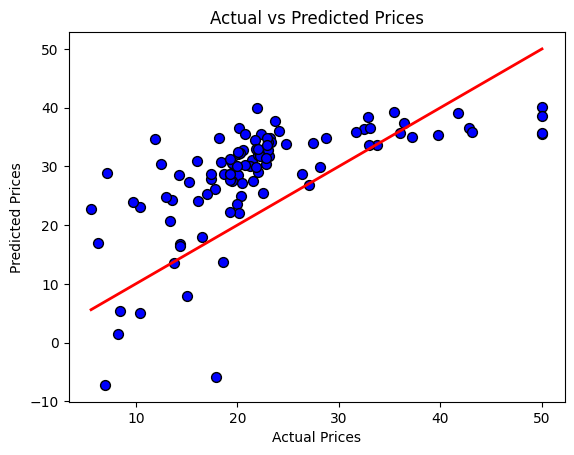

In [ ]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error

# 다양한 epsilon 값
epsilon_values = [0.1,0.5,1, 5, 10, 20, 30, 50]

# 성능 기록용 리스트
test_errors = []
models = {}

# 모델 훈련 및 평가
for epsilon in epsilon_values:
    svr = LinearSVR(epsilon=epsilon, random_state=42, max_iter=10000)
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    test_errors.append(mse)
    models[epsilon] = svr

# 성능 분석
best_epsilon = epsilon_values[np.argmin(test_errors)]
worst_epsilon = epsilon_values[np.argmax(test_errors)]

print(f"Best epsilon: {best_epsilon}, MSE: {min(test_errors)}")
print(f"Worst epsilon: {worst_epsilon}, MSE: {max(test_errors)}")

Best epsilon: 0.1, MSE: 53.06353992613618
Worst epsilon: 50, MSE: 592.6328431372549


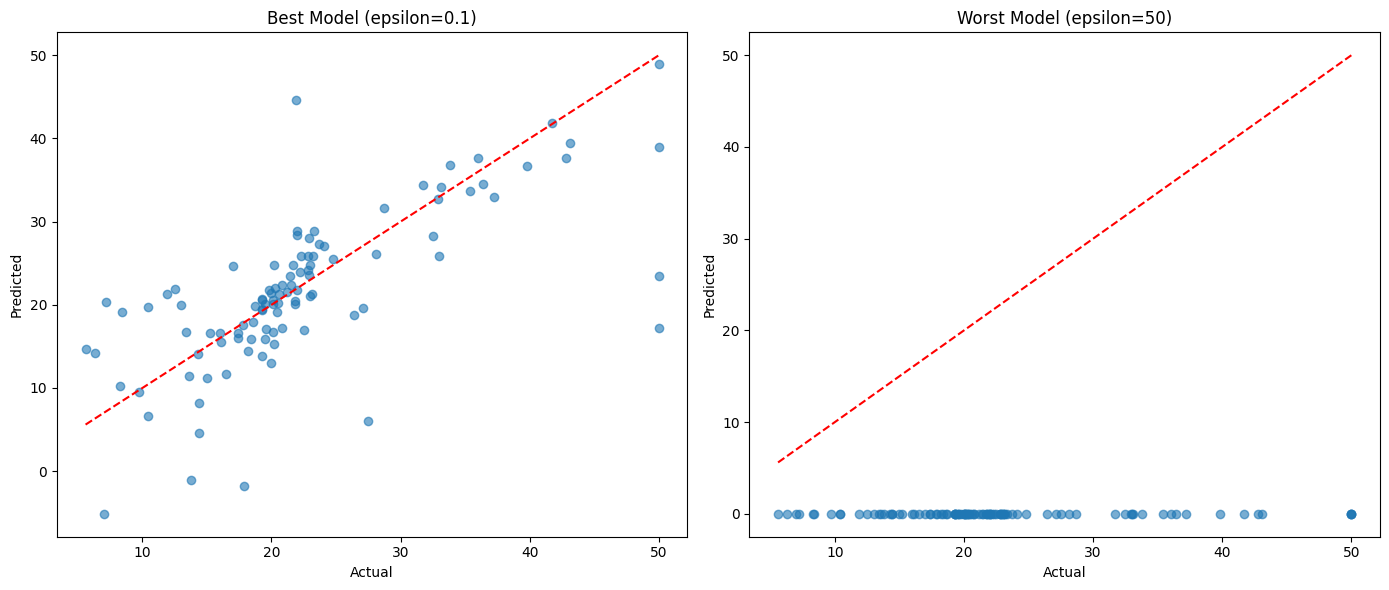

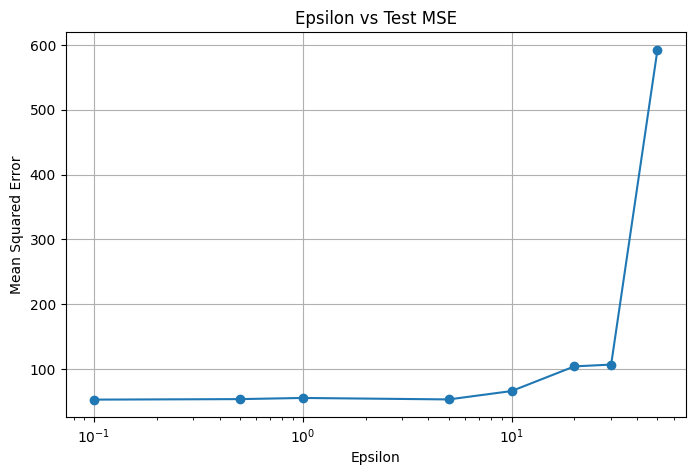

In [ ]:
# Todo

# 예측 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 가장 좋은 모델
y_best_pred = models[best_epsilon].predict(X_test)
axes[0].scatter(y_test, y_best_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'Best Model (epsilon={best_epsilon})')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# 가장 나쁜 모델
y_worst_pred = models[worst_epsilon].predict(X_test)
axes[1].scatter(y_test, y_worst_pred, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'Worst Model (epsilon={worst_epsilon})')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# 성능 변화 시각화
plt.figure(figsize=(8, 5))
plt.plot(epsilon_values, test_errors, marker='o')
plt.xlabel('Epsilon')
plt.ylabel('Mean Squared Error')
plt.title('Epsilon vs Test MSE')
plt.xscale('log')
plt.grid(True)
plt.show()

Epsilon은,실제값과 예측값 간의 차이중에서 반영할 것과 반영하지 않을 것의 경계를 결정짓는 역할을 하고, epsilon값이 클 수록 threshold가 크기 때문에 대부분의 예측값과 실제값의 차이가 손실(Loss)로 반영되지 않는다. Epsilon의 크기가 커질수록 underfitting의 경향이 높아지므로 그래프에서도 관찰할 수 있듯이, Test error가 커진다.

****

# 과제 1-2 : SVM 분류

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [ ]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

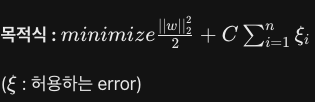


In [ ]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01,0.05,0.1,0.2,0.5,1,1.5,2,5,10,20] # Todo
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.05:
Training Accuracy: 0.95
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

-------------------

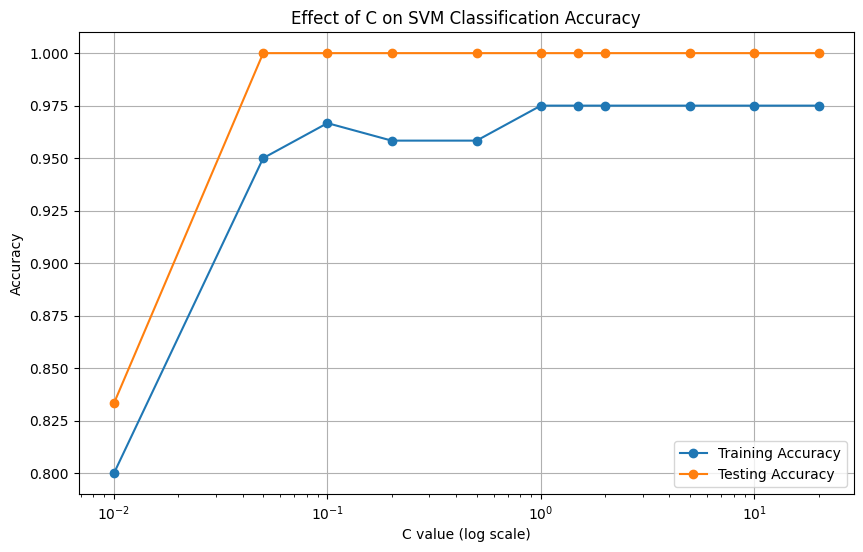

In [ ]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()